<a href="https://colab.research.google.com/github/Sergei-Bothhh/Sales-Analytics-/blob/main/Python_for_DA_Module_Task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount("/content/drive")
%cd /content/drive/MyDrive/Mate/Python

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/Mate/Python


In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
events = pd.read_csv("events.csv")
events.head()

,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost
0,100640618,10/8/2014,10/18/2014,M,NOR,2103,Online,650.0,205.70,117.11
1,100983083,8/11/2016,8/11/2016,C,SRB,2103,Offline,1993.0,205.70,117.11
2,101025998,7/18/2014,8/11/2014,M,NaN,7940,Online,4693.0,668.27,502.54
3,102230632,5/13/2017,6/13/2017,L,MNE,2455,Online,1171.0,109.28,35.84
4,103435266,8/11/2012,9/18/2012,H,SRB,1270,Offline,7648.0,47.45,31.79


In [ ]:
events["Country Code"] = events["Country Code"].fillna("Unknown")
events_cle = events.dropna().copy()
print(events_cle.isna().sum() / events_cle.shape[0] * 100)

Order ID          0.0
Order Date        0.0
Ship Date         0.0
Order Priority    0.0
Country Code      0.0
Product ID        0.0
Sales Channel     0.0
Units Sold        0.0
Unit Price        0.0
Unit Cost         0.0
dtype: float64


In [ ]:
events_cle["Order Date"] = pd.to_datetime(events_cle["Order Date"],format="%m/%d/%Y")
events_cle["Ship Date"] = pd.to_datetime(events_cle["Ship Date"],format="%m/%d/%Y")
events_cle.columns = events_cle.columns.str.lower().str.replace(" ","_")
#events_cle = events_cle.drop_duplicates()
events_cle.head()

,order_id,order_date,ship_date,order_priority,country_code,product_id,sales_channel,units_sold,unit_price,unit_cost
0,100640618,2014-10-08,2014-10-18,M,NOR,2103,Online,650.0,205.70,117.11
1,100983083,2016-08-11,2016-08-11,C,SRB,2103,Offline,1993.0,205.70,117.11
2,101025998,2014-07-18,2014-08-11,M,Unknown,7940,Online,4693.0,668.27,502.54
3,102230632,2017-05-13,2017-06-13,L,MNE,2455,Online,1171.0,109.28,35.84
4,103435266,2012-08-11,2012-09-18,H,SRB,1270,Offline,7648.0,47.45,31.79


In [ ]:
events_cle.describe()

,order_id,order_date,ship_date,product_id,units_sold,unit_price,unit_cost
count,1.328000e+03,1328,1328,1328.000000,1328.000000,1328.000000,1328.000000
mean,5.416231e+08,2013-10-11 22:28:54.939759104,2013-11-05 17:22:02.891566336,5787.775602,4952.201807,264.913245,187.211521
min,1.006406e+08,2010-01-01 00:00:00,2010-01-10 00:00:00,1270.000000,2.000000,9.330000,6.920000
25%,3.213291e+08,2011-12-14 06:00:00,2012-01-02 00:00:00,3127.000000,2356.750000,81.730000,35.840000
50%,5.399925e+08,2013-10-15 12:00:00,2013-11-05 12:00:00,5988.000000,4962.000000,154.060000,97.440000
75%,7.547357e+08,2015-08-29 12:00:00,2015-10-04 18:00:00,8681.000000,7459.500000,437.200000,263.330000
max,9.998797e+08,2017-07-23 00:00:00,2017-08-31 00:00:00,8969.000000,9999.000000,668.270000,524.960000
std,2.573496e+08,NaN,NaN,2820.635702,2905.198996,217.386320,176.187801


In [ ]:
text_cols = events_cle.select_dtypes(include=["object"]).columns

for col in text_cols:
    events_cle[col] = events_cle[col].str.strip()
print(f"Дублікатів до очищення тексту: {events_cle.duplicated().sum()}")

Дублікатів до очищення тексту: 0


In [ ]:
events.describe()

,Order ID,Product ID,Units Sold,Unit Price,Unit Cost
count,1.330000e+03,1330.000000,1328.000000,1330.000000,1330.000000
mean,5.412048e+08,5788.096241,4952.201807,264.893541,187.246812
std,2.573882e+08,2820.728878,2905.198996,217.323460,176.158873
min,1.006406e+08,1270.000000,2.000000,9.330000,6.920000
25%,3.190004e+08,3127.000000,2356.750000,81.730000,35.840000
50%,5.387164e+08,5988.000000,4962.000000,154.060000,97.440000
75%,7.544628e+08,8681.000000,7459.500000,437.200000,263.330000
max,9.998797e+08,8969.000000,9999.000000,668.270000,524.960000


In [ ]:
products = pd.read_csv("products.csv")
products.head()

,id,item_type
0,2103,Cereal
1,7940,Household
2,2455,Clothes
3,1270,Beverages
4,8681,Office Supplies


In [ ]:
products = products.rename(columns={"id": "product_id"})

In [ ]:
products_cle = products.dropna()
print(products_cle.isna().sum() / products_cle.shape[0] * 100)

product_id    0.0
item_type     0.0
dtype: float64


In [ ]:
countries = pd.read_csv("countries.csv")
countries.head()

,name,alpha-2,alpha-3,region,sub-region
0,Afghanistan,AF,AFG,Asia,Southern Asia
1,Åland Islands,AX,ALA,Europe,Northern Europe
2,Albania,AL,ALB,Europe,Southern Europe
3,Algeria,DZ,DZA,Africa,Northern Africa
4,American Samoa,AS,ASM,Oceania,Polynesia


In [ ]:
countries_cle = countries.dropna()
print(countries_cle.isna().sum() / countries_cle.shape[0] * 100)

name          0.0
alpha-2       0.0
alpha-3       0.0
region        0.0
sub-region    0.0
dtype: float64


In [ ]:
countries_cle = countries_cle.rename(columns={"name": "country"})
countries_cle = countries_cle.rename(columns={"alpha-3": "country_code"})
countries_cle.head()

,country,alpha-2,country_code,region,sub-region
0,Afghanistan,AF,AFG,Asia,Southern Asia
1,Åland Islands,AX,ALA,Europe,Northern Europe
2,Albania,AL,ALB,Europe,Southern Europe
3,Algeria,DZ,DZA,Africa,Northern Africa
4,American Samoa,AS,ASM,Oceania,Polynesia


In [ ]:
outer = pd.merge(events_cle,products_cle,on="product_id",how="left")
df = pd.merge(outer,countries_cle,on="country_code",how="left")
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1328 entries, 0 to 1327
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_id        1328 non-null   int64         
 1   order_date      1328 non-null   datetime64[ns]
 2   ship_date       1328 non-null   datetime64[ns]
 3   order_priority  1328 non-null   object        
 4   country_code    1328 non-null   object        
 5   product_id      1328 non-null   int64         
 6   sales_channel   1328 non-null   object        
 7   units_sold      1328 non-null   float64       
 8   unit_price      1328 non-null   float64       
 9   unit_cost       1328 non-null   float64       
 10  item_type       1328 non-null   object        
 11  country         1246 non-null   object        
 12  alpha-2         1246 non-null   object        
 13  region          1246 non-null   object        
 14  sub-region      1246 non-null   object        
dtypes: d

In [ ]:
df["country"] = df["country"].bfill()
df["region"] = df["region"].bfill()
df["sub-region"] = df["sub-region"].bfill()

In [ ]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1328 entries, 0 to 1327
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_id        1328 non-null   int64         
 1   order_date      1328 non-null   datetime64[ns]
 2   ship_date       1328 non-null   datetime64[ns]
 3   order_priority  1328 non-null   object        
 4   country_code    1328 non-null   object        
 5   product_id      1328 non-null   int64         
 6   sales_channel   1328 non-null   object        
 7   units_sold      1328 non-null   float64       
 8   unit_price      1328 non-null   float64       
 9   unit_cost       1328 non-null   float64       
 10  item_type       1328 non-null   object        
 11  country         1328 non-null   object        
 12  alpha-2         1246 non-null   object        
 13  region          1328 non-null   object        
 14  sub-region      1328 non-null   object        
dtypes: d

In [ ]:
df.describe()

,order_id,order_date,ship_date,product_id,units_sold,unit_price,unit_cost
count,1.328000e+03,1328,1328,1328.000000,1328.000000,1328.000000,1328.000000
mean,5.416231e+08,2013-10-11 22:28:54.939759104,2013-11-05 17:22:02.891566336,5787.775602,4952.201807,264.913245,187.211521
min,1.006406e+08,2010-01-01 00:00:00,2010-01-10 00:00:00,1270.000000,2.000000,9.330000,6.920000
25%,3.213291e+08,2011-12-14 06:00:00,2012-01-02 00:00:00,3127.000000,2356.750000,81.730000,35.840000
50%,5.399925e+08,2013-10-15 12:00:00,2013-11-05 12:00:00,5988.000000,4962.000000,154.060000,97.440000
75%,7.547357e+08,2015-08-29 12:00:00,2015-10-04 18:00:00,8681.000000,7459.500000,437.200000,263.330000
max,9.998797e+08,2017-07-23 00:00:00,2017-08-31 00:00:00,8969.000000,9999.000000,668.270000,524.960000
std,2.573496e+08,NaN,NaN,2820.635702,2905.198996,217.386320,176.187801


In [ ]:
print(f"--- Ключові метрики ---")
print(f"Загальна кількість замовлень: {df["order_id"].nunique()}")
print(f"Загальна кількість країн:    {df["country"].nunique()}")
print(f"Продано одиниць товару:      {df["units_sold"].sum()}")

--- Ключові метрики ---
Загальна кількість замовлень: 1328
Загальна кількість країн:    45
Продано одиниць товару:      6576524.0


In [ ]:
df["profit"] = df["unit_price"] * df["units_sold"] - df["unit_cost"] * df["units_sold"]
df["revenue"] = df["unit_price"] * df["units_sold"]
df["total_cost"] = df["units_sold"] * df["unit_cost"]
df["sales_channel"] = df["sales_channel"].str.capitalize()
df.head()

,order_id,order_date,ship_date,order_priority,country_code,product_id,sales_channel,units_sold,unit_price,unit_cost,item_type,country,alpha-2,region,sub-region,profit,revenue,total_cost
0,100640618,2014-10-08,2014-10-18,M,NOR,2103,Online,650.0,205.70,117.11,Cereal,Norway,NO,Europe,Northern Europe,57583.50,133705.00,76121.50
1,100983083,2016-08-11,2016-08-11,C,SRB,2103,Offline,1993.0,205.70,117.11,Cereal,Serbia,RS,Europe,Southern Europe,176559.87,409960.10,233400.23
2,101025998,2014-07-18,2014-08-11,M,Unknown,7940,Online,4693.0,668.27,502.54,Household,Montenegro,NaN,Europe,Southern Europe,777770.89,3136191.11,2358420.22
3,102230632,2017-05-13,2017-06-13,L,MNE,2455,Online,1171.0,109.28,35.84,Clothes,Montenegro,ME,Europe,Southern Europe,85998.24,127966.88,41968.64
4,103435266,2012-08-11,2012-09-18,H,SRB,1270,Offline,7648.0,47.45,31.79,Beverages,Serbia,RS,Europe,Southern Europe,119767.68,362897.60,243129.92


In [ ]:
order_list = df.groupby("item_type")["profit"].mean().sort_values().index
order_l = df.groupby("item_type")["revenue"].mean().sort_values().index
order_cost = df.groupby("item_type")["total_cost"].mean().sort_values().index

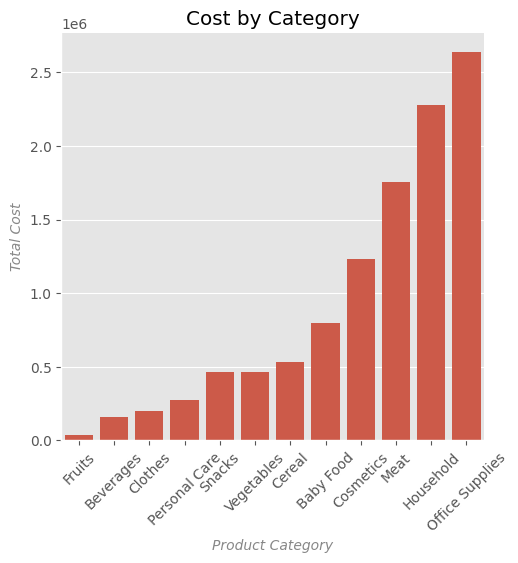

In [ ]:
plt.style.use("ggplot")
sns.catplot(x="item_type", y="total_cost", kind="bar", errorbar=("ci", False), data=df,order=order_cost)
plt.title("Cost by Category")
plt.xticks(rotation=45)
plt.xlabel("Product Category",alpha=0.7,fontstyle="italic",fontsize=10)
plt.ylabel("Total Cost",alpha=0.7,fontstyle="italic",fontsize=10)
plt.show()

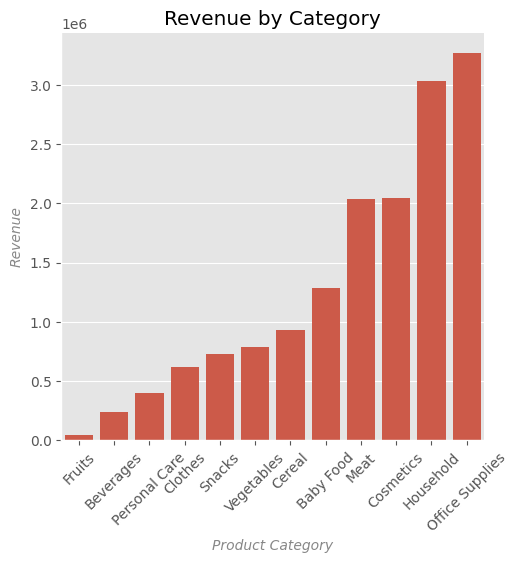

In [ ]:
plt.style.use("ggplot")
sns.catplot(x="item_type", y="revenue", kind="bar", errorbar=("ci", False), data=df,order=order_l)
plt.title("Revenue by Category")
plt.xticks(rotation=45)
plt.xlabel("Product Category",alpha=0.7,fontstyle="italic",fontsize=10)
plt.ylabel("Revenue",alpha=0.7,fontstyle="italic",fontsize=10)
plt.show()

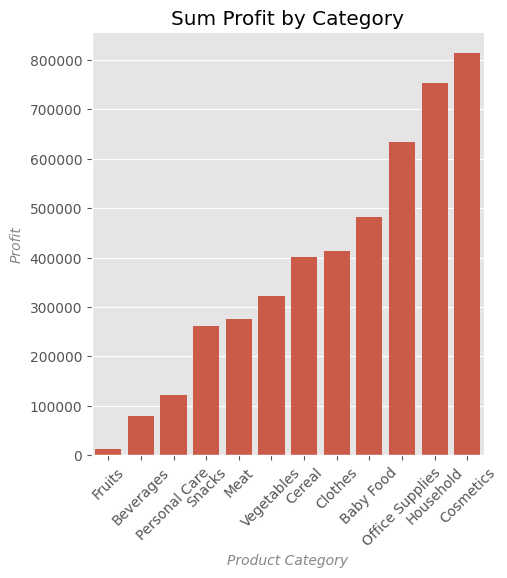

In [ ]:
plt.style.use("ggplot")
sns.catplot(x="item_type", y="profit", kind="bar", errorbar=("ci", False), data=df,order=order_list)
plt.title("Sum Profit by Category")
plt.xticks(rotation=45)
plt.xlabel("Product Category",alpha=0.7,fontstyle="italic",fontsize=10)
plt.ylabel("Profit",alpha=0.7,fontstyle="italic",fontsize=10)
plt.show()

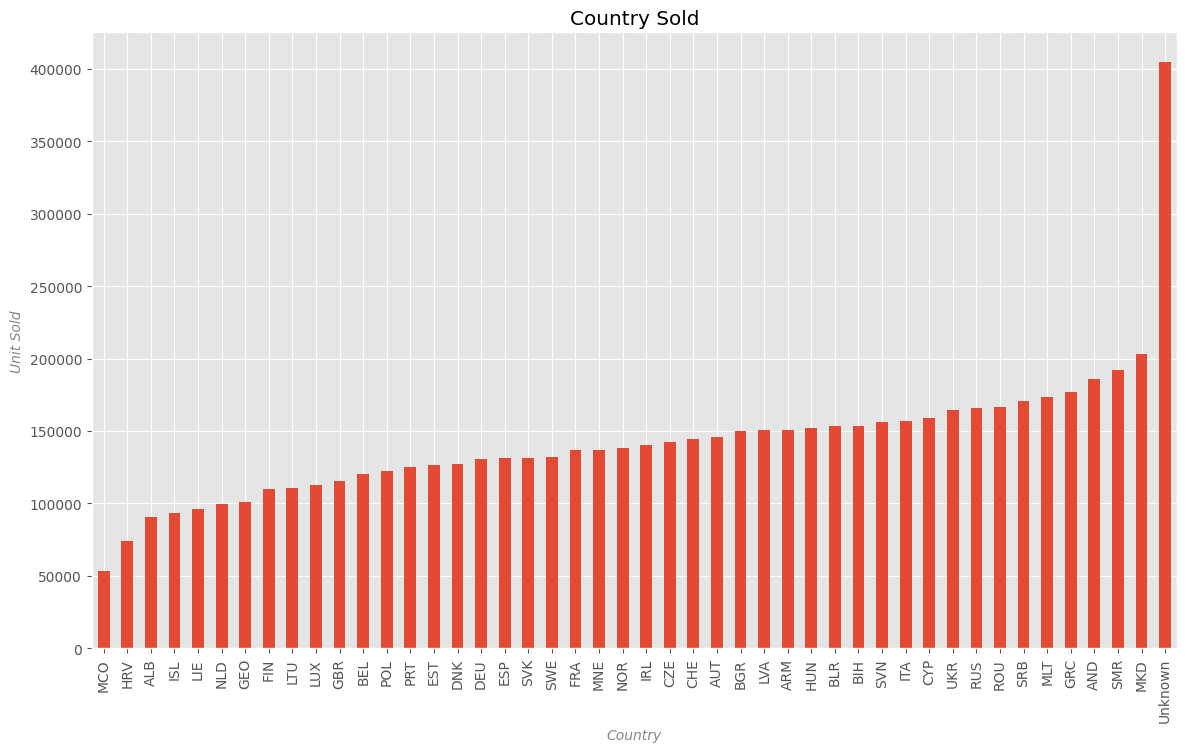

In [ ]:
plt.figure(figsize = (14,8))
country_sold = df.groupby("country_code")["units_sold"].sum().sort_values()
country_sold.plot(kind = "bar")
plt.title("Country Sold")
plt.xlabel("Country",alpha=0.7,fontstyle="italic",fontsize=10)
plt.ylabel("Unit Sold",alpha=0.7,fontstyle="italic",fontsize=10)
plt.show()

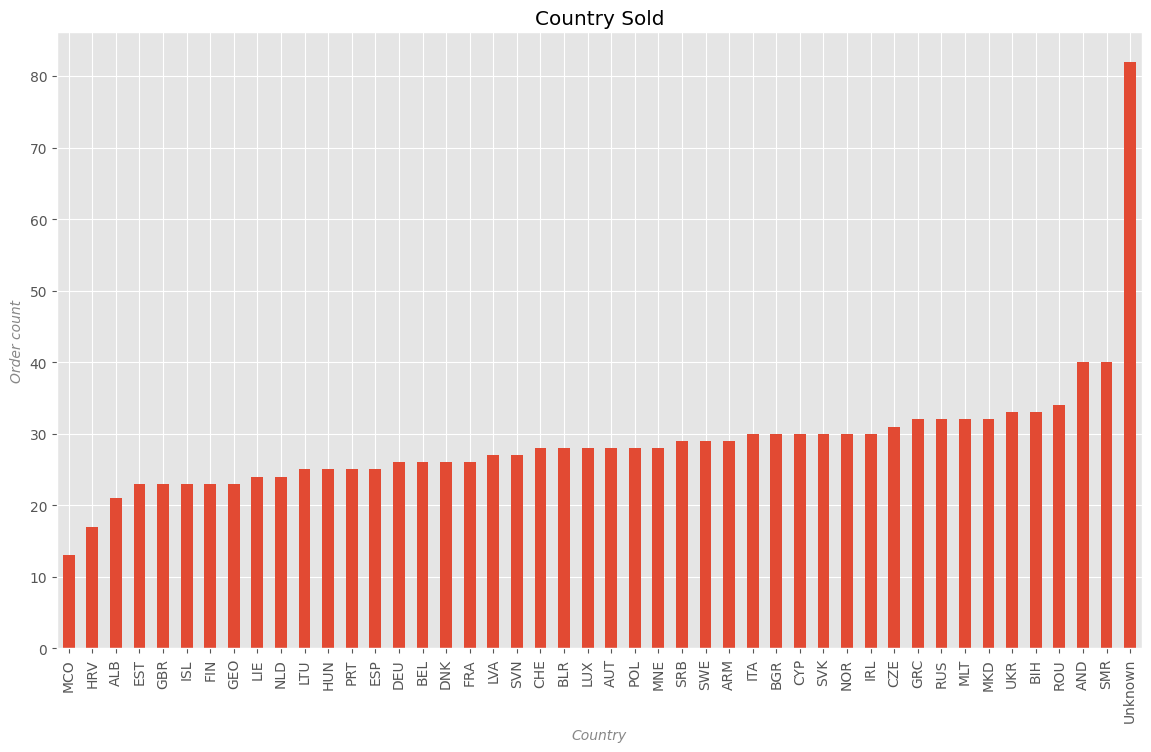

In [ ]:
plt.figure(figsize = (14,8))
country_order = df.groupby("country_code")["order_id"].count().sort_values()
country_order.plot(kind = "bar")
plt.title("Country Sold")
plt.xlabel("Country",alpha=0.7,fontstyle="italic",fontsize=10)
plt.ylabel("Order count",alpha=0.7,fontstyle="italic",fontsize=10)
plt.show()

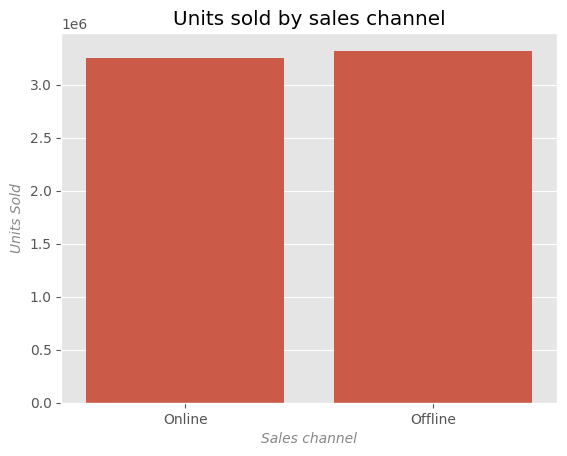

In [ ]:
channel_sales = df.groupby("sales_channel")["units_sold"].sum().sort_values()
sns.barplot(x = channel_sales.index, y = channel_sales.values)
plt.title("Units sold by sales channel")
plt.xlabel("Sales channel",alpha=0.7,fontstyle="italic",fontsize=10)
plt.ylabel("Units Sold",alpha=0.7,fontstyle="italic",fontsize=10)
plt.show()

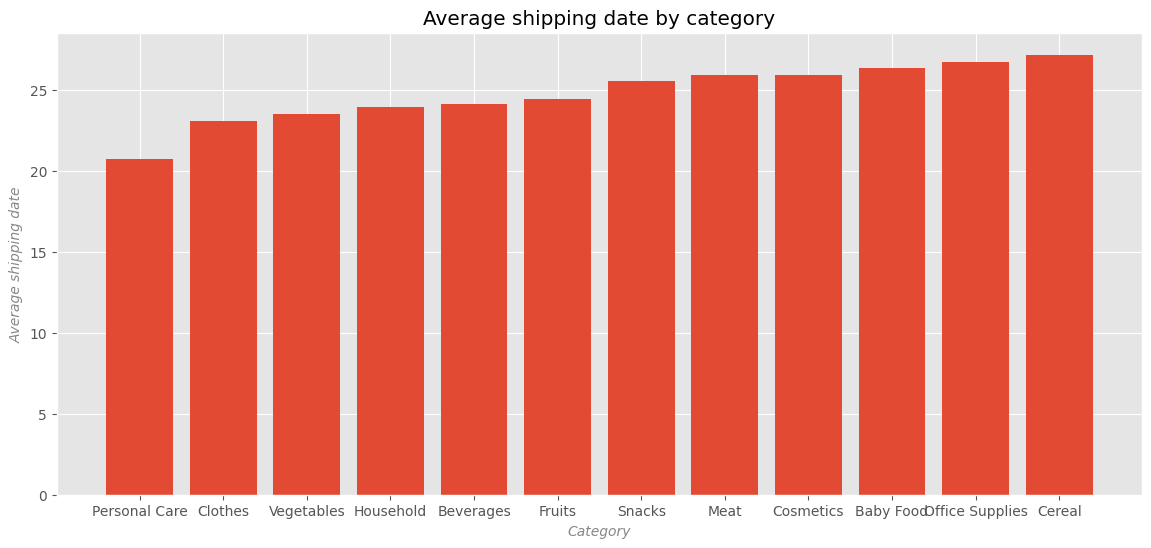

In [ ]:
df["order_date"] = pd.to_datetime(df["order_date"])
df["ship_date"] = pd.to_datetime(df["ship_date"])
df["shipping_time"] = (df["ship_date"] - df["order_date"]).dt.days
average_shipping_date_by_category = df.groupby("item_type")["shipping_time"].mean().sort_values()
plt.figure(figsize = (14, 6))
plt.bar(average_shipping_date_by_category.index, average_shipping_date_by_category.values)
plt.title("Average shipping date by category")
plt.xlabel("Category",alpha=0.7,fontstyle="italic",fontsize=10)
plt.ylabel("Average shipping date",alpha=0.7,fontstyle="italic",fontsize=10)
plt.show()

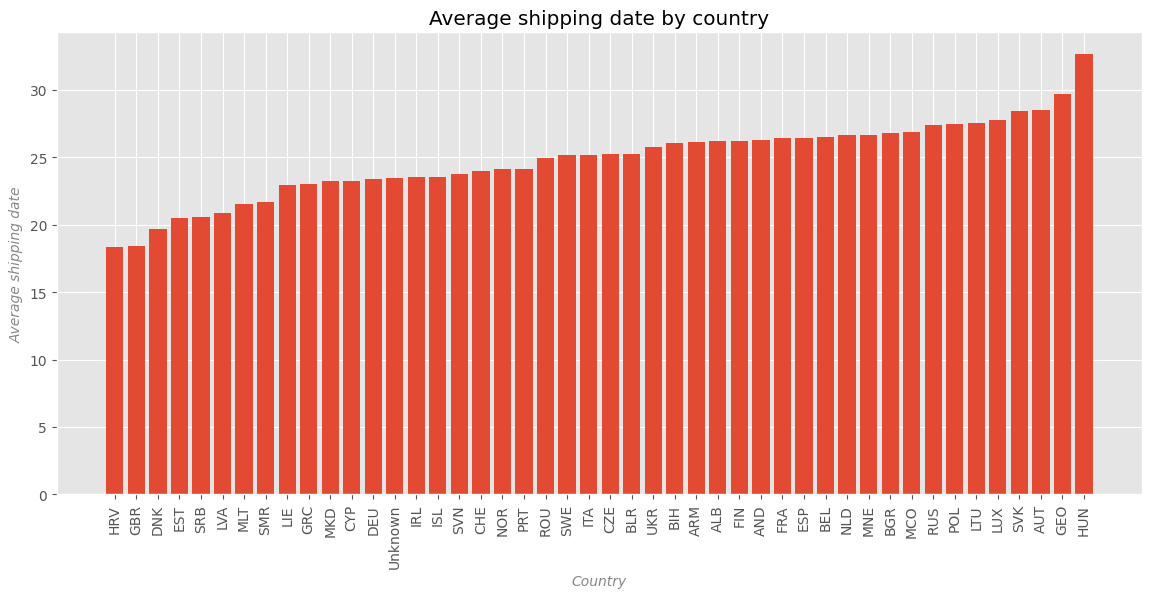

In [ ]:
average_shipping_date_by_country = df.groupby("country_code")["shipping_time"].mean().sort_values()
plt.figure(figsize = (14, 6))
plt.bar(average_shipping_date_by_country.index, average_shipping_date_by_country.values)
plt.title("Average shipping date by country")
plt.xticks(rotation=90)
plt.xlabel("Country",alpha=0.7,fontstyle="italic",fontsize=10)
plt.ylabel("Average shipping date",alpha=0.7,fontstyle="italic",fontsize=10)
plt.show()

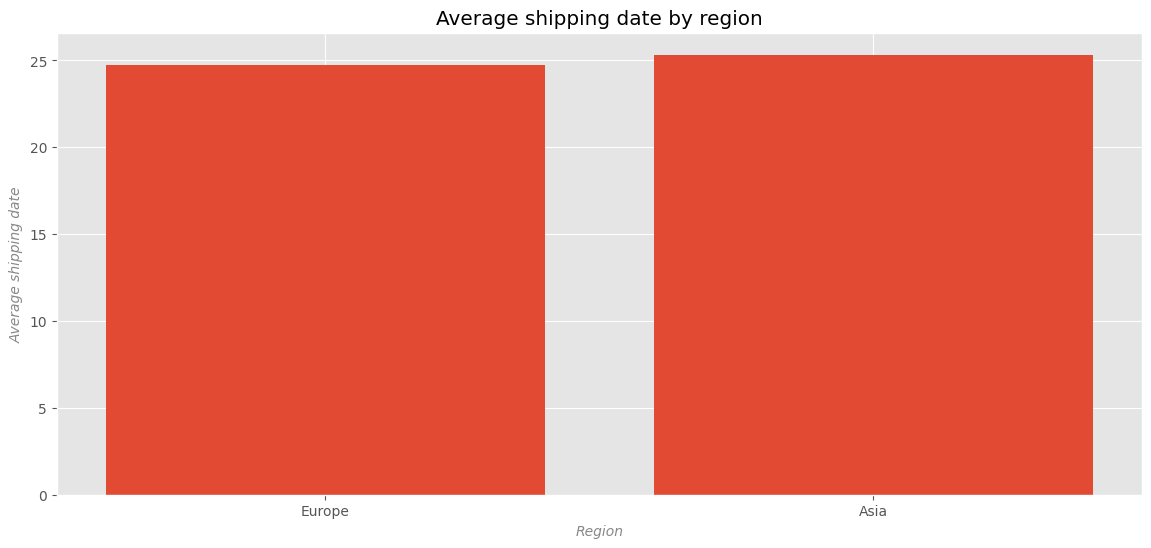

In [ ]:
average_shipping_date_by_region= df.groupby("region")["shipping_time"].mean().sort_values()
plt.figure(figsize = (14, 6))
plt.bar(average_shipping_date_by_region.index, average_shipping_date_by_region.values)
plt.title("Average shipping date by region")
plt.xlabel("Region",alpha=0.7,fontstyle="italic",fontsize=10)
plt.ylabel("Average shipping date",alpha=0.7,fontstyle="italic",fontsize=10)
plt.show()

Text(0, 0.5, 'Profit')

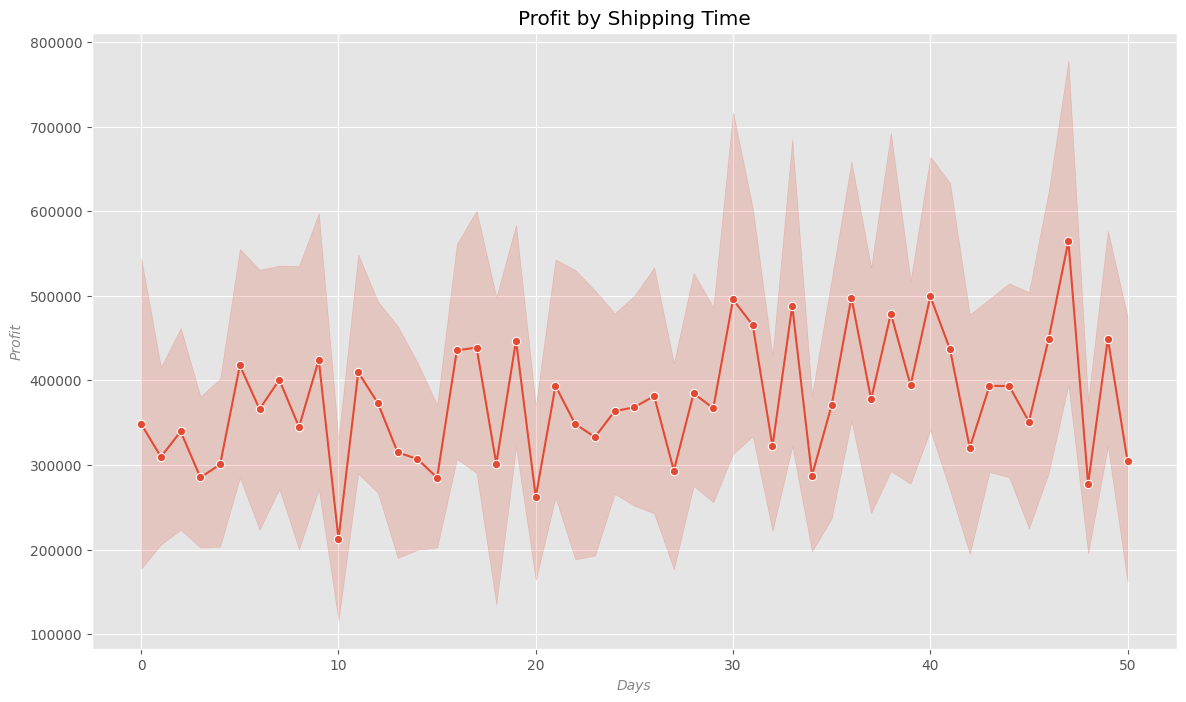

In [ ]:
plt.figure(figsize=(14,8))
sns.lineplot(data=df, x="shipping_time", y="profit", marker="o")
plt.title("Profit by Shipping Time")
plt.xlabel("Days",alpha=0.7,fontstyle="italic",fontsize=10)
plt.ylabel("Profit",alpha=0.7,fontstyle="italic",fontsize=10)

In [ ]:
df["year_month"] = df["order_date"].dt.to_period('M').dt.to_timestamp()
df["year"] = df["order_date"].dt.to_period("Y").dt.to_timestamp()
global_dynamics = df.groupby("year_month")["revenue"].sum().reset_index()
category_dynamics = df.groupby(["year", "item_type"])["revenue"].sum().reset_index()
region_dynamics = df.groupby(["year", "region"])["revenue"].sum().reset_index()

/tmp/ipykernel_2460/3168698247.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 0.1)` for the same effect.

  sns.lineplot(data=category_dynamics, x="year", y="revenue", hue="item_type", linewidth=2,ci=0.1)


<Axes: xlabel='year', ylabel='revenue'>

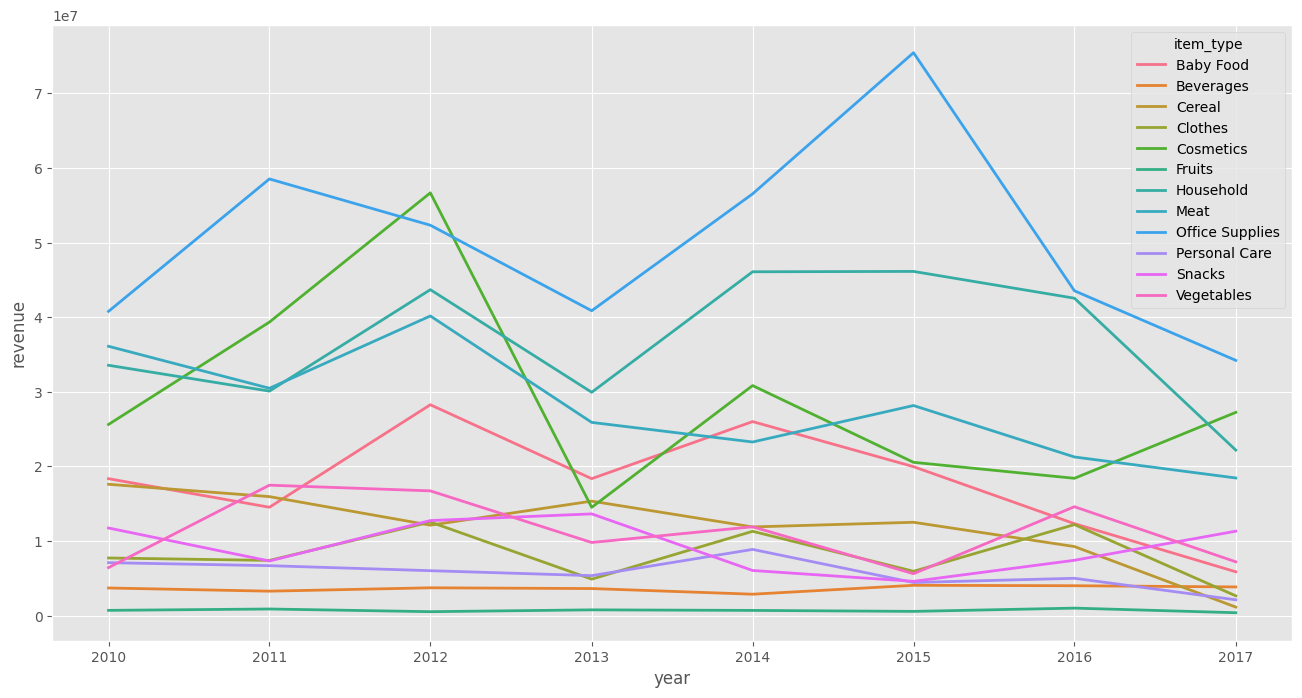

In [ ]:
plt.figure(figsize=(16, 8))
sns.lineplot(data=category_dynamics, x="year", y="revenue", hue="item_type", linewidth=2,ci=0.1)

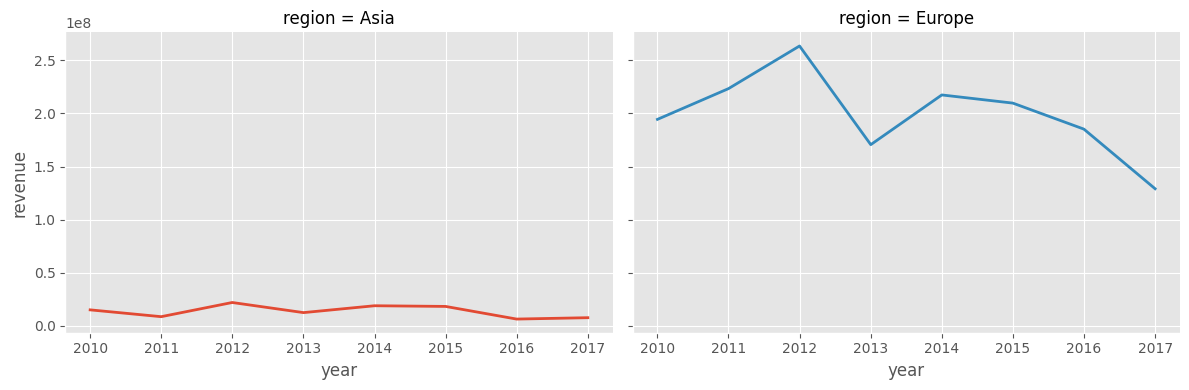

In [ ]:
sns.relplot(data=region_dynamics,x="year", y="revenue",col="region",col_wrap=2,kind="line",
    height=4, aspect=1.5,hue="region",linewidth=2,legend=False)

In [ ]:
top_countries = df.groupby("country")["revenue"].sum().nlargest(5).index
df_top_countries = df[df["country"].isin(top_countries)]
country_dynamics = df_top_countries.groupby(["year", "country"])["revenue"].sum().reset_index()

<Axes: xlabel='year', ylabel='revenue'>

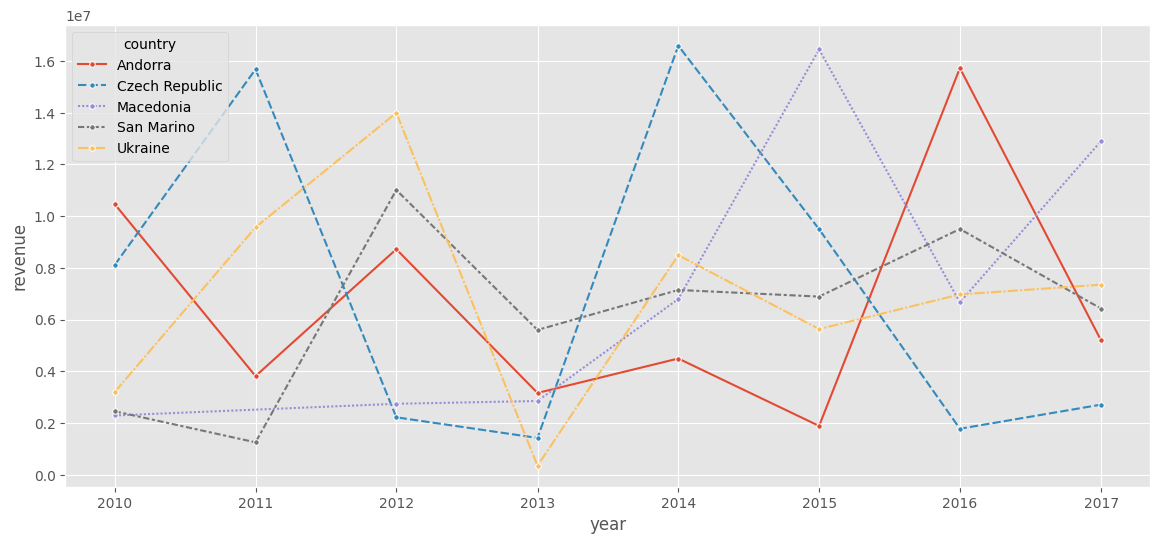

In [ ]:
plt.figure(figsize=(14, 6))
sns.lineplot(data=country_dynamics, x="year", y="revenue", hue="country", style="country", marker="o", markersize=4, linewidth=1.5)

In [ ]:
df["day_name"] = df["order_date"].dt.day_name()
days_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

<Axes: xlabel='day_name', ylabel='profit'>

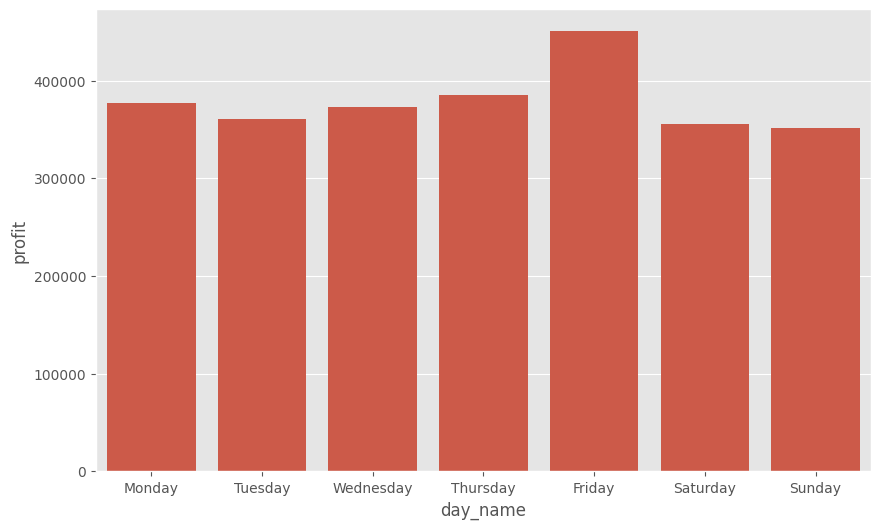

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x="day_name", y="profit", order=days_order, errorbar=None)

In [ ]:
df["month"] = df["order_date"].dt.month
seasonal_data = df.groupby(["month", "item_type"])["profit"].mean().reset_index()

<Axes: xlabel='month', ylabel='profit'>

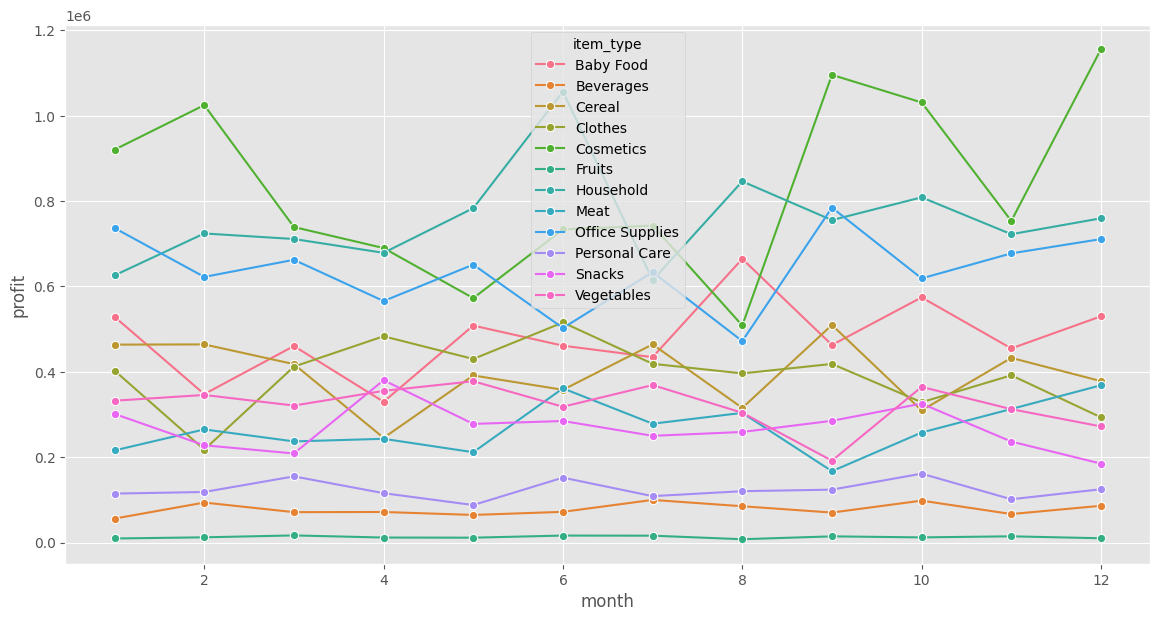

In [ ]:
plt.figure(figsize=(14, 7))
sns.lineplot(data=seasonal_data, x="month", y="profit", hue="item_type", marker="o")

Ключові метрики ---
Загальна кількість замовлень: 1328
Загальна кількість країн:    45
Продано одиниць товару:      6576524.0

Можна зробити висновок, що найприбутковішими категоріями є Office Supplies, Household та Cosmetics, оскільки вони демонструють найвищий сумарний прибуток та дохід, що робить їх ключовими активами бізнесу, тоді як категорії Meat та Baby Food мають стабільні показники доходу, але нижчу маржинальність, а Fruits, Beverages та Personal Care залишаються аутсайдерами з найнижчим оборотом. Графік витрат Cost by Category майже дублює структуру доходів, що свідчить про модель великого обороту в лідируючих сегментах, де значні інвестиції приносять пропорційно високу віддачу. Географічний аналіз показує, що більшість країн мають рівень продажів від 100,000 до 150,000 юнітів, проте існує аномальний лідер у категорії Unknown або MKD/SMR, де показники перевищують 400,000 одиниць, що може вказувати на великий неуточнений ринок або похибку в даних. За кількістю замовлень більшість країн генерують від 20 до 40 транзакцій, тоді як лідируюча група подвоює цей показник. Аналіз каналів збуту за графіком Units sold by sales channel демонструє майже рівномірний розподіл між Online та Offline із незначною перевагою останнього, що підкреслює важливість фізичних точок продажу.

Аналіз середнього інтервалу між замовленням та відвантаженням показує, що найшвидша обробка замовлень відбувається в категоріях Personal Care, Clothes та Vegetables, де час очікування становить приблизно 21 день, тоді як найповільнішими є Cereal, Office Supplies та Baby Food з показником близько 27 днів, що може вказувати на складніші логістичні процеси або специфіку пакування цих товарів. У розрізі країн спостерігається значна географічна диференціація, де лідерами за швидкістю є Хорватія, Велика Британія та Данія з показником 18-19 днів, тоді як в Угорщині час відвантаження є критично високим і перевищує 33 дні, що потребує перегляду місцевих логістичних ланцюжків або митних процедур. Порівняння за регіонами демонструє, що Європа працює дещо оперативніше з середнім показником близько 24-25 днів, у той час як в Азії цей інтервал становить приблизно 26 днів, хоча загальна різниця між регіонами залишається невеликою і не перевищує двох діб.

Аналіз графіка Profit by Shipping Time демонструє відсутність прямої лінійної залежності між часом відвантаження товару та отриманим прибутком, оскільки лінія тренду має виражений коливальний (волатильний) характер без чіткого зростання або спадання при збільшенні кількості днів на доставку. Ми бачимо, що високі показники прибутку в діапазоні від 400,000 до 600,000 одиниць досягаються як при швидкому відвантаженні (наприклад, близько 5–7 днів), так і при тривалому очікуванні (понад 45 днів), що свідчить про те, що фінансовий результат більше залежить від обсягу замовлення або типу товару в категорії, ніж від швидкості логістики.Таким чином, бізнес залишається прибутковим навіть при тривалих термінах доставки.

Аналіз часової динаміки доходів з 2010 по 2017 рік у розрізі категорій товарів демонструє високу сезонну волатильність із регулярними піками продажів, де найбільш стабільне зростання та найвищі амплітуди доходів спостерігаються у категоріях Household, Office Supplies та Cosmetics, тоді як Meat демонструє різкі, але менш часті сплески активності, а Baby Food та Cereal зберігають помірний рівень стабільності протягом усього періоду. Регіональний розріз чітко вказує на домінуючу роль європейського ринку, де обсяги доходів у кілька разів перевищують азійські показники, причому в Європі динаміка характеризується щільним графіком замовлень та вищою частотою фінансових піків, тоді як азійський регіон розвивається менш інтенсивно з поодинокими значними зростаннями, наприклад, у 2013 та 2014 роках. Динаміка по п’яти ключових країнах — Андоррі, Чехії, Сан-Марино, Україні та Македонії — показує відсутність єдиного тренду, оскільки кожна країна має індивідуальні періоди максимальної активності, наприклад, Україна демонструє помітний сплеск доходів у 2012 році, Чехія — на межі 2015 року, а Македонія показує стрімке зростання наприкінці 2017 року, що робить її найбільш перспективним ринком у поточному тренді. Загальною тенденцією для всіх вимірів є відсутність довгострокового стабільного зростання.

Аналіз прибутку за днями тижня на основі графіка sns.barplot показує, що найбільш продуктивним днем для бізнесу є п'ятниця, коли середній прибуток помітно перевищує 400,000 одиниць, у той час як в інші будні та вихідні дні показники тримаються на відносно стабільному рівні в межах 350,000–380,000 одиниць, що може свідчити про закриття великих контрактів або підвищення споживчої активності наприкінці робочого тижня. Щодо сезонності, то лінійний графік прибутку за місяцями підтверджує наявність сезонних товарів, зокрема категорія Cosmetics демонструє чітко виражені піки активності в березні, червні та листопаді-грудні, що збігається з періодами свят та розпродажів, тоді як категорія Household показує циклічне зростання у квітні, серпні та жовтні, що може бути пов'язано з підготовкою до сезонів прибирання або оновлення оселі. Офісні товари (Office Supplies) та дитяче харчування (Baby Food) демонструють більш помірну, але також хвилеподібну динаміку з піком у липні-серпні, що для офісних товарів може пояснюватися сезоном , тоді як категорії Fruits та Beverages залишаються стабільно низькими протягом року без явних сезонних коливань.